In [1]:
# the decision boundaries of different Van Krevelen area definitions using supervised classification can be quite artsy, so here we visualise them in a more appealing way

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

In [2]:
df_path = '../new_vk_areas_df.csv'
dpi = 1200

In [3]:
df = pd.read_csv(df_path)
df_2D = df[['category','O/C','H/C','weights']]
df_3D = df[['category','O/C','H/C','N/C','weights']]
weighted = True
poly_degree = 3

In [4]:
vk_region_colours = {
    'lipid': '#F5C308',
    'peptide': '#BD3A53',

    'carbohydrate': '#0040FF',
    'amino_sugar': '#7C9EBF',
    
    'lignin': '#33251E',
    'tannin': '#CE833B',

    'pah': "#808080",

    'unassigned': '#e6e6e6'
}


def train_test(X, y,train_size=0.8,weighted_yn=weighted,random_state=5):
    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=train_size, random_state=random_state)

    if weighted_yn:
        class_weights_train = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
        class_weights_test = compute_class_weight('balanced', classes=np.unique(y_test), y=y_test)

        weights_dict_train = {cls: weight for cls, weight in zip(np.unique(y_train), class_weights_train)}
        weights_dict_test = {cls: weight for cls, weight in zip(np.unique(y_test), class_weights_test)}

        weights_train = np.array([weights_dict_train[cat] for cat in y_train])
        weights_test = np.array([weights_dict_test[cat] for cat in y_test])
    
    else:
        weights_train = None
        weights_test = None

    return X_train, X_test, y_train, y_test, weights_train, weights_test


def draw_decision_boundary_plot(estimator, X, categories, xlim=None, ylim=None, xlabel=None, ylabel=None, title=None, savepath=None,
                                level_step=0.1,grid_resolution=500,colors_dict=None,legend=True,
                                class_of_interest=None,cmap=None,dpi=dpi):
    fig, ax = plt.subplots()

    levels = np.arange(0, 1 + level_step, level_step) if level_step else None # levels for contour plots

    disp = DecisionBoundaryDisplay.from_estimator(
        estimator,
        X,
        response_method="predict_proba",
        plot_method="contourf", # contourf, contour, pcolormesh
        ax=ax,
        grid_resolution=grid_resolution,
        levels=levels,
        multiclass_colors=[colors_dict[cat] for cat in categories] if colors_dict else None,
        class_of_interest=class_of_interest,
        cmap=cmap,
    )

    for cat in categories:
        cat_mod = cat.replace('_',' ').capitalize() + '-like'
        if 'Pah' in cat_mod:
            cat_mod = 'PAH-like'
        ax.scatter(None,None,zorder=1,alpha=1,label=cat_mod,c=colors_dict[cat] if colors_dict else None)

    if level_step:
        for level in np.arange(level_step, 1 + level_step, level_step):
            ax.plot([None,None],[None,None],
                    c='k',alpha=level,lw=10,label=f'{(100*level):.0f}% probability')
   
    if legend: ax.legend(framealpha=1,bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0,fontsize=12)

    if xlim: ax.set_xlim(xlim)
    if ylim: ax.set_ylim(ylim)

    if xlabel: ax.set_xlabel(xlabel, fontsize=14)
    if ylabel: ax.set_ylabel(ylabel, fontsize=14)

    if title: ax.set_title(title, fontsize=16)

    if savepath: fig.savefig(savepath, dpi = dpi, bbox_inches='tight')

    return fig, ax


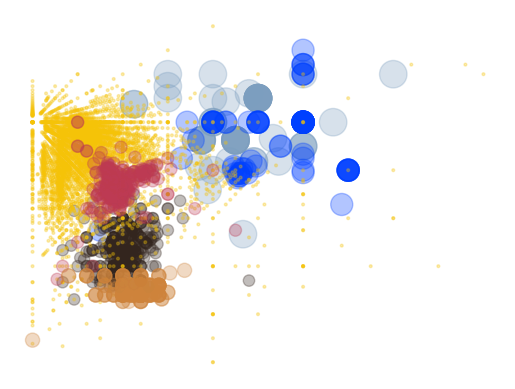

In [6]:
#plot the Van Krevelen diagram
fig, ax = plt.subplots()

for category in df['category'].unique():
    subset = df[df['category'] == category]
    ax.scatter(subset['O/C'], subset['H/C'], c = vk_region_colours[category],
               alpha=0.3, s=df[df['category'] == category]['weights']*20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
fig.savefig('art/vk_diagram.svg', dpi = dpi, facecolor = '#fff', bbox_inches='tight', pad_inches=0)
fig.savefig('art/vk_diagram.png', dpi = dpi, facecolor = '#fff', bbox_inches='tight', pad_inches=0)

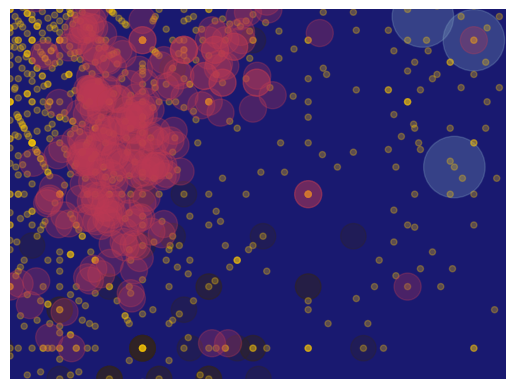

In [7]:
#plot the Van Krevelen diagram
fig, ax = plt.subplots()

for category in df['category'].unique():
    subset = df[df['category'] == category]
    ax.scatter(subset['O/C'], subset['H/C'], c = vk_region_colours[category],
               alpha=0.3, s=df[df['category'] == category]['weights']*1e2)

ax.set_xlim(.2,.699)
ax.set_ylim(1.3,1.7)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_facecolor('#191970')

fig.savefig('art/vk_diagram_zoom1.svg', dpi = dpi, bbox_inches='tight', pad_inches=0)
fig.savefig('art/vk_diagram_zoom1.png', dpi = dpi, bbox_inches='tight', pad_inches=0)

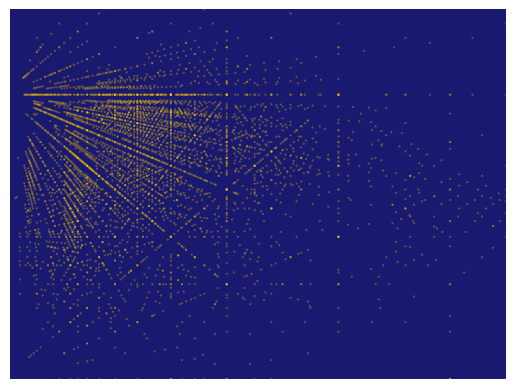

In [8]:
#plot the Van Krevelen diagram
fig, ax = plt.subplots()

for category in df['category'].unique():
    if category == 'lipid':
        subset = df[df['category'] == category]
        ax.scatter(subset['O/C'], subset['H/C'], c = vk_region_colours[category],
                alpha=0.3, s=df[df['category'] == category]['weights']*2)

ax.set_xlim(0.01,.75)
ax.set_ylim(1,2.3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_facecolor('#191970')

fig.savefig('art/vk_diagram_lipids1.svg', dpi = dpi, bbox_inches='tight', pad_inches=0)
fig.savefig('art/vk_diagram_lipids1.png', dpi = dpi, bbox_inches='tight', pad_inches=0)

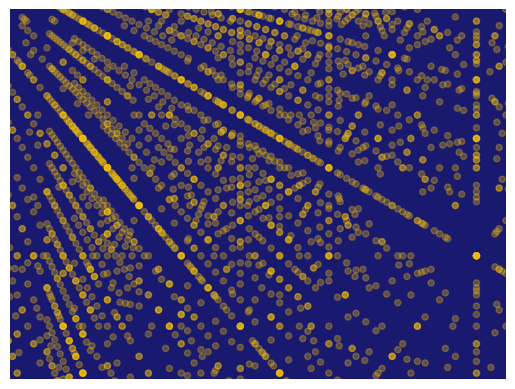

In [9]:
#plot the Van Krevelen diagram
fig, ax = plt.subplots()

for category in df['category'].unique():
    if category == 'lipid':
        subset = df[df['category'] == category]
        ax.scatter(subset['O/C'], subset['H/C'], c = vk_region_colours[category],
                alpha=0.3, s=df[df['category'] == category]['weights']*1e2)

ax.set_xlim(0.07,.35)
ax.set_ylim(1.55,1.9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_facecolor('#191970')

fig.savefig('art/vk_diagram_lipids2.svg', dpi = dpi, bbox_inches='tight', pad_inches=0)
fig.savefig('art/vk_diagram_lipids2.png', dpi = dpi, bbox_inches='tight', pad_inches=0)

In [5]:
X = df_2D[['O/C','H/C']].to_numpy()
y = df_2D['category'].to_numpy()
weights = df_2D['weights'].to_numpy()

In [6]:
# train all classifiers with the entire dataset
gnb_overall = CalibratedClassifierCV(GaussianNB()).fit(X, y, sample_weight=weights if weighted else None)
svc_poly_overall = CalibratedClassifierCV(SVC(kernel="poly",degree=poly_degree,gamma='auto',probability=True)).fit(X, y, sample_weight=weights if weighted else None)
svc_rbf_overall = CalibratedClassifierCV(SVC(kernel="rbf", C=100, gamma=1, probability=True)).fit(X, y, sample_weight=weights if weighted else None)

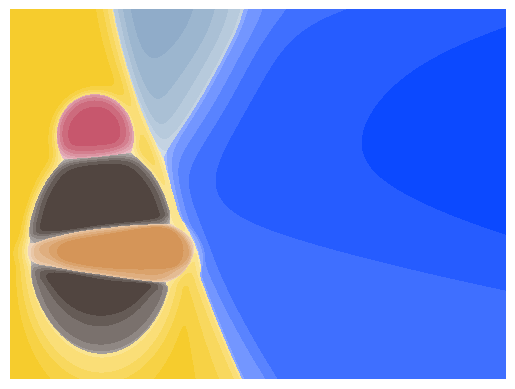

In [12]:
fig, ax = draw_decision_boundary_plot(gnb_overall,
                                      X,
                                      categories=np.unique(y),
                                      colors_dict=vk_region_colours,
                                      legend=False,
                                      grid_resolution=2000
                                      )

ax.set_xlim(0,2)
ax.set_ylim(0,2.3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
fig.savefig('art/gnb.svg', dpi = dpi, bbox_inches='tight', pad_inches=0)
fig.savefig('art/gnb.png', dpi = dpi, bbox_inches='tight', pad_inches=0)

In [ ]:
fig, ax = draw_decision_boundary_plot(svc_poly_overall,
                                      X,
                                      categories=np.unique(y),
                                      colors_dict=vk_region_colours,
                                      legend=False,
                                      grid_resolution=2000
                                      )

ax.set_xlim(-0.5,2.6)
ax.set_ylim(0,3.5)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.set_xticks([])
ax.set_yticks([])
fig.savefig('art/svc-poly.svg', dpi = dpi, bbox_inches='tight', pad_inches=0)
fig.savefig('art/svc-poly.png', dpi = dpi, bbox_inches='tight', pad_inches=0)

In [ ]:
fig, ax = draw_decision_boundary_plot(svc_poly_overall,
                                      X,
                                      categories=np.unique(y),
                                      cmap='ocean',
                                      legend=False,
                                      class_of_interest='carbohydrate',
                                      grid_resolution=2000
                                      )

ax.set_xlim(.1,2.6)
ax.set_ylim(0.3,3.5)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.set_xticks([])
ax.set_yticks([])
fig.savefig('art/svc-poly-carbohydrate.svg', dpi = dpi, bbox_inches='tight', pad_inches=0)
fig.savefig('art/svc-poly-carbohydrate.png', dpi = dpi, bbox_inches='tight', pad_inches=0)

In [ ]:
fig, ax = draw_decision_boundary_plot(svc_rbf_overall,
                                      X,
                                      categories=np.unique(y),
                                      colors_dict=vk_region_colours,
                                      legend=False,
                                      grid_resolution=2000
                                    )

ax.set_xlim(-1,2.7)
ax.set_ylim(-.5,3.5)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.set_xticks([])
ax.set_yticks([])
fig.savefig('art/svc-rbf.svg', dpi = dpi, bbox_inches='tight', pad_inches=0)
fig.savefig('art/svc-rbf.png', dpi = dpi, bbox_inches='tight', pad_inches=0)